In [1]:
import pandas as pd
import numpy as np
np.random.seed(0)
import matplotlib.pyplot as plt
data = pd.read_csv("XYZloan_default_selected_vars.csv")

In [2]:
# Drop columns with more than a threshold of missing values
threshold = 0.9 * data.shape[0]
columns_to_drop = data.columns[data.isna().sum() > threshold]
data_cleaned = data.drop(columns=columns_to_drop)

print(f"Dropped columns: {list(columns_to_drop)}")

Dropped columns: ['TD044', 'TD048', 'TD051', 'TD054', 'TD055', 'TD061', 'TD062']


In [3]:
# Drop columns with object dtype

data_cleaned=data_cleaned.drop(['AP005','AP006','MB007'],axis=1)

In [4]:
for col in ['TD022', 'TD023', 'TD024', 'TD025', 'TD026', 'TD027', 'TD028', 'TD029', 'PA022', 'PA023', 
            'PA028', 'PA029', 'PA030', 'PA031', 'CD008', 'CD018', 'CD071', 'CD072', 'CD088', 'CD100', 
            'CD101', 'CD106', 'CD107', 'CD108', 'CD113', 'CD114', 'CD115', 'CD117', 'CD118', 'CD120',
            'CD121', 'CD123', 'CD130', 'CD131', 'CD132', 'CD133', 'CD135', 'CD136', 'CD137', 'CD152', 
            'CD153', 'CD160', 'CD162', 'CD164', 'CD166', 'CD167', 'CD169', 'CD170', 'CD172', 'CD173', 
            'MB005']:
    data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)

/var/folders/zy/c768xsdd6214ck3ylckgprhh0000gn/T/ipykernel_53696/3802641048.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)


In [5]:
predictors = ['TD013', 'AP003', 'MB005', 'CR015', 'TD005', 'PA029', 'TD009', 'PA028', 'AP002', 'AP007']

In [6]:
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.ensemble import RandomForestRegressor
# The target variable is 'quality'.
Y = data_cleaned['loan_default']
X =  data_cleaned[predictors]
# Split the data into train and test data:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2)
# Build the model with the random forest regression algorithm:
model = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=100, random_state=0)
model.fit(X_train, Y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=100, n_estimators=300,
                      random_state=0)

In [7]:
#!pip install shap

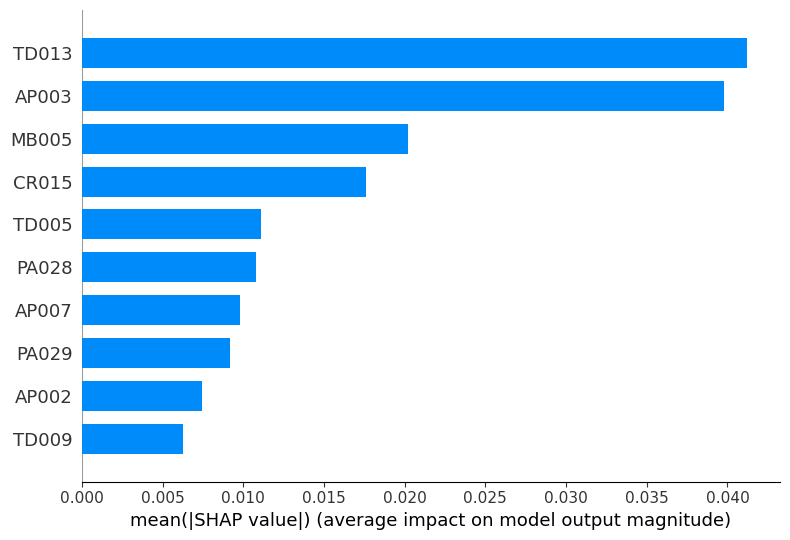

In [8]:
import shap
shap_values = shap.TreeExplainer(model).shap_values(X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar")

TD013 and AP003 have similar levels of influence, making them the most important features contributing significantly to the model's predictive output. MB005 ranks third, also showing a notable impact. Other features, such as CR015 and TD005, have gradually diminishing effects on the predictions.

In [9]:
rf_shap_values = shap.TreeExplainer(model).shap_values(X_test)

## Summary_plot

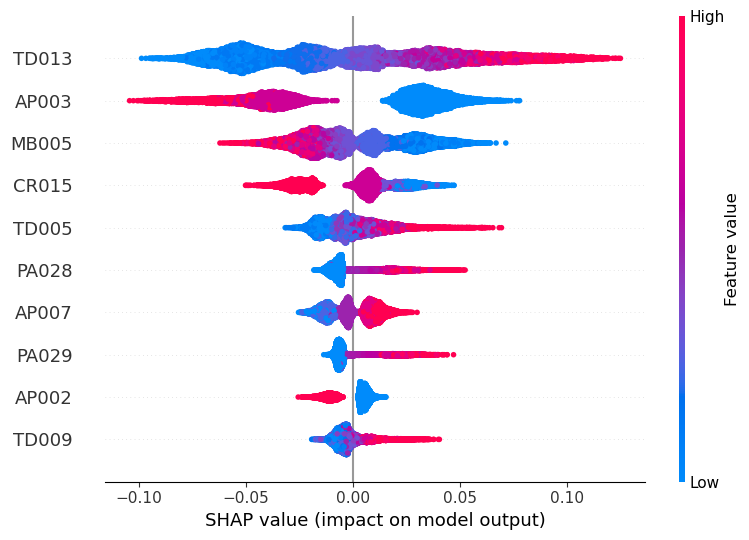

In [10]:
import matplotlib.pyplot as plt
f = plt.figure()
shap.summary_plot(rf_shap_values, X_test)
f.savefig("summary_plot1.png", bbox_inches='tight', dpi=600)

1. **TD013 (TD_CNT_QUERY_LAST_6MON_P2P)**:
   - It has the widest distribution and the most extreme SHAP values, confirming it as the most important feature.
   - High values (red) positively influence the prediction, likely indicating higher credit risk with more P2P queries in the past six months.

2. **AP003 (CODE_EDUCATION)**:
   - Its SHAP values show both positive and negative effects on the prediction.
   - Lower education levels (blue) tend to increase risk, while higher education levels (red) reduce risk.

3. **MB005 (YR_PHONE_ACTIVE)**:
   - Longer phone usage (red) lowers the prediction (indicating lower risk), while shorter usage (blue) increases it.

4. **CR015 (MONTH_CREDIT_CARD_MOB_MAX)**:
   - A longer credit card history (red) generally reduces risk, reflected by SHAP values close to zero or negative.

5. **TD005 (TD_CNT_QUERY_LAST_1MON_P2P)**:
   - High recent query counts (red) increase the prediction, highlighting short-term financial pressure.

6. **PA028 and PA029 (High-Risk Call Durations)**:
   - Longer call durations (red) slightly decrease risk, possibly reflecting more cooperative clients.

7. **TD009 (TD_CNT_QUERY_LAST_3MON_P2P)**:
   - Query counts over three months (red) affect the prediction, but less significantly than TD013 or TD005.

In [11]:
import os
print(os.getcwd())  # Prints the current working directory

/Users/cathyzhang/Documents/5420/Assignment12


## Dependence_plot

### Extensive descriptions for top 5 variables

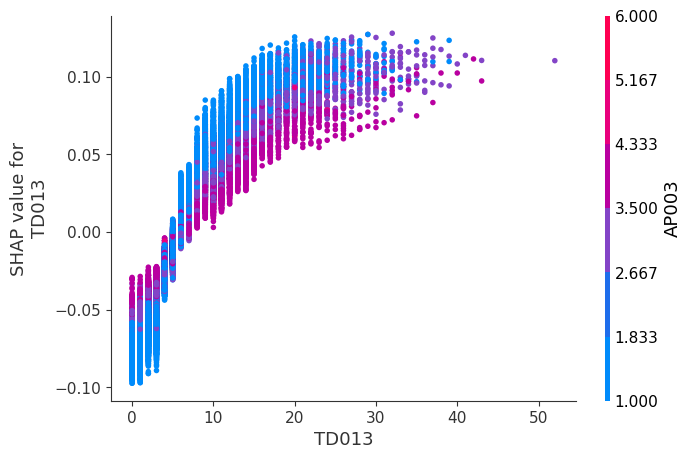

In [12]:
shap.dependence_plot("TD013", shap_values, X_train)

This plot shows how **TD013** (the number of P2P loan queries in the last 6 months) impacts the model's predictions, with **AP003** (education level) highlighted as a color gradient.
- As the number of P2P queries (TD013) increases, the impact on the model's prediction grows, meaning more P2P queries indicate a higher credit risk.
- Lower education levels (blue) are more associated with higher risk when combined with frequent P2P queries.
- Higher education levels (red) seem to reduce the risk impact, even when P2P query counts are high.        

In conclusion:    
People with more than 20 P2P queries and lower education levels should be flagged for closer review, as they represent a high-risk group. Those with frequent queries but higher education might still be reliable, as education appears to balance out the risk.

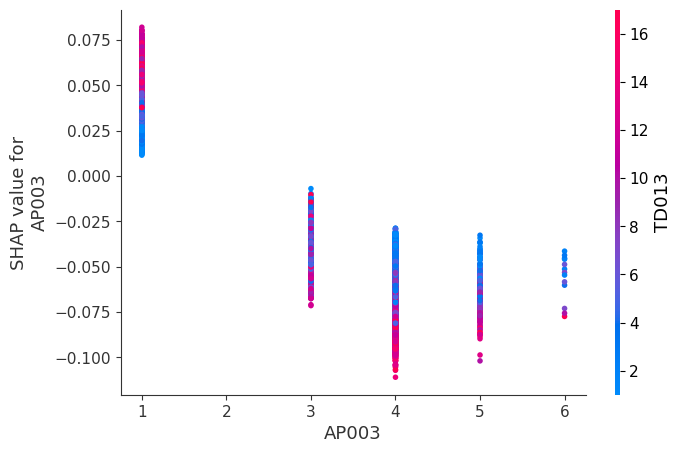

In [13]:
shap.dependence_plot("AP003", shap_values, X_train)

This plot shows how **AP003** (education level) affects the model's predictions, with **TD013** (number of P2P queries in the last 6 months) represented by the color gradient.
- Higher education levels tend to reduce predicted risk, as seen from the negative SHAP values. This effect is even stronger when the number of P2P queries (TD013) is low (blue).
- Lower education levels increase predicted risk, as shown by positive SHAP values. This risk is amplified when P2P queries are high (red).

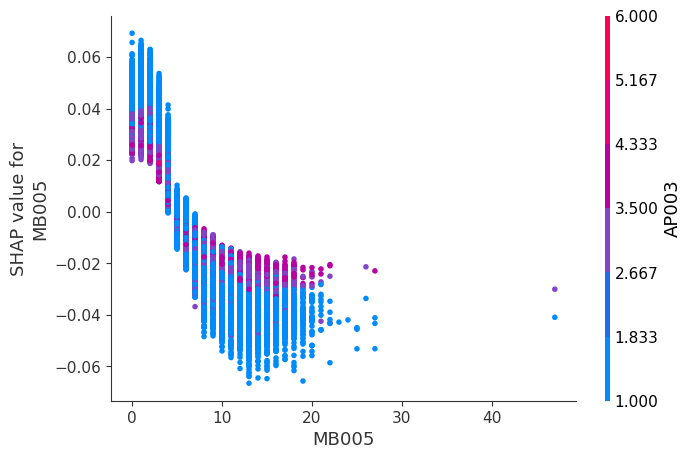

In [14]:
shap.dependence_plot("MB005", shap_values, X_train)

This plot shows the relationship between **MB005** (years the phone number has been active) and its SHAP value, with **AP003** (education level) represented as a color gradient.
- Shorter phone usage's SHAP values are mostly positive, meaning shorter phone usage increases predicted risk.
- Longer phone usage's SHAP values become negative, meaning longer phone usage reduces risk significantly.
- This reflects the model's assumption that stable, long-term phone usage correlates with lower risk.
- Higher education levels tend to reduce risk overall, even for those with shorter phone usage.

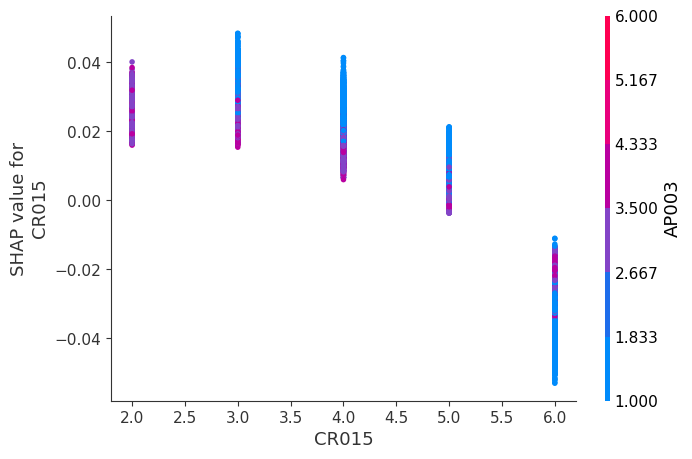

In [15]:
shap.dependence_plot("CR015", shap_values, X_train)

This plot shows the relationship between **CR015** (maximum credit card activity months) and its SHAP values, with **AP003** (education level) represented as a color gradient.
- Higher CR015 values's SHAP values are negative, indicating that longer credit card activity history reduces predicted risk. The stability provided by a long credit history is reflected in the reduced risk prediction.
- Lower CR015 values's SHAP values are positive, meaning shorter credit card activity history increases risk. This suggests that a limited credit history is viewed as a potential indicator of higher risk.
- Higher education levels tend to lower risk overall, even for individuals with shorter credit card activity history.

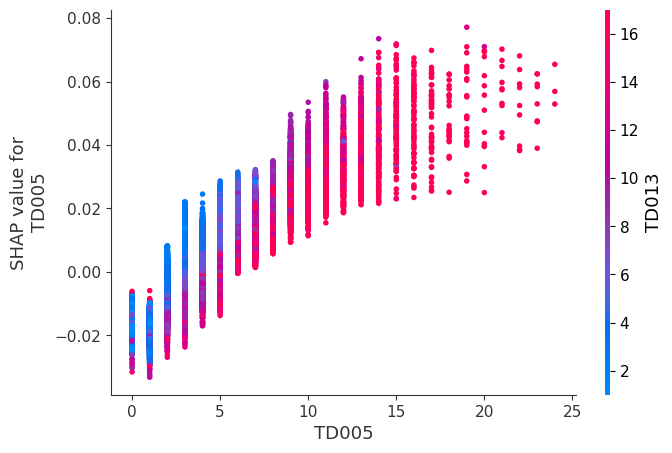

In [16]:
shap.dependence_plot("TD005", shap_values, X_train)

This plot shows the relationship between **TD005** (P2P query counts in the last month) and its SHAP values, with **TD013** (P2P query counts in the last 6 months) represented as a color gradient.
- As TD005 increases, the SHAP values also increase significantly, indicating that more P2P queries in the last month strongly contribute to a higher predicted risk.
- When TD005 is close to zero, SHAP values are neutral or slightly negative, indicating minimal or no contribution to risk.
- Higher TD013 values amplify the risk impact of TD005. For example, individuals with both high TD005 and TD013 have the highest SHAP values, signaling a strong risk profile.
- Lower TD013 values moderate the impact of TD005, even when TD005 is high. This suggests that individuals with fewer P2P queries over the last 6 months but high activity in the last month may be viewed as less risky.

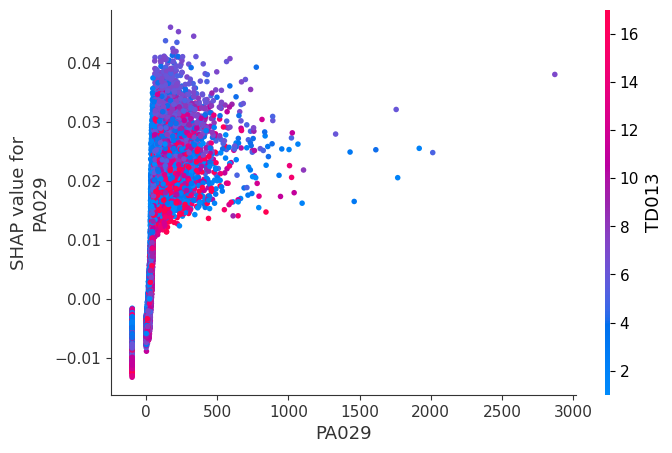

In [17]:
shap.dependence_plot("PA029", shap_values, X_train)

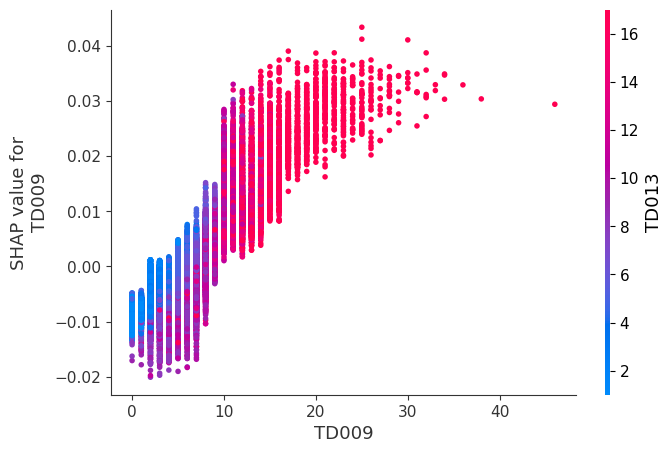

In [18]:
shap.dependence_plot("TD009", shap_values, X_train)

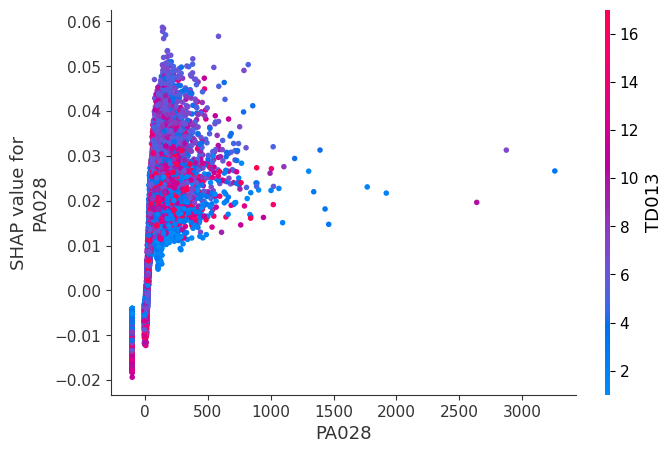

In [19]:
shap.dependence_plot("PA028", shap_values, X_train)

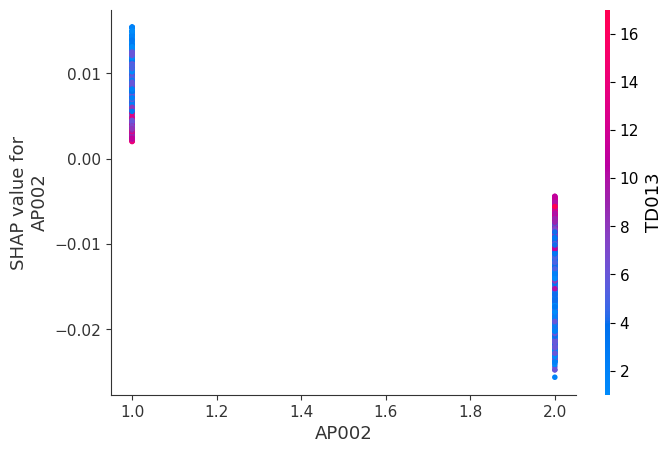

In [20]:
shap.dependence_plot("AP002", shap_values, X_train)

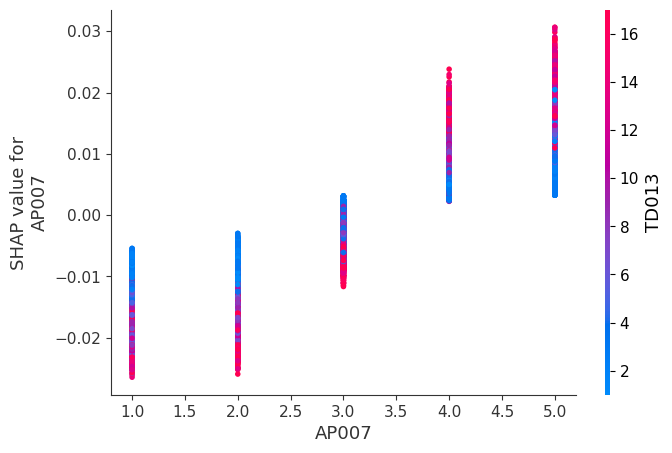

In [21]:
shap.dependence_plot("AP007", shap_values, X_train)

## Force_plot for 4 individual observations

In [22]:
# Get the predictions and put them with the test data.
X_output = X_test.copy()
X_output.loc[:,'predict'] = np.round(model.predict(X_output),2)

S = X_output.iloc[:4]

In [23]:
# Initialize your Jupyter notebook with initjs(), otherwise you will get an error message.
shap.initjs()

# Write in a function
def shap_plot(j):
    explainerModel = shap.TreeExplainer(model)
    shap_values_Model = explainerModel.shap_values(S)
    p = shap.force_plot(explainerModel.expected_value, shap_values_Model[j], S.iloc[[j]])
    return(p)

In [24]:
shap_plot(0)

The prediction of 0.18 reflects a slightly lower-than-average risk. This individual has a balanced risk profile, with stability indicators slightly outweighing risk factors, leading to a prediction below the baseline.

In [25]:
shap_plot(1)

The prediction of 0.21 reflects a slightly higher-than-average risk due to a combination of short-term credit-seeking behavior and limited financial history. However, mitigating factors like education and the absence of high-risk call indicators balance the prediction, preventing it from being significantly higher. 

In [26]:
shap_plot(2)

The prediction of 0.18 reflects a slightly lower-than-average risk. While some moderate risk factors are present (e.g., P2P queries, education level), they are effectively offset by indicators of stability such as long phone usage, low recent P2P activity, and the absence of high-risk behaviors.

In [27]:
shap_plot(3)

The prediction of 0.18 reflects a slightly lower-than-average risk. While some factors (e.g., high P2P query activity, short phone usage history) contribute to increased risk, they are effectively offset by mitigating factors such as credit history, education level, and the absence of high-risk behavior. 

In [28]:
print(data_cleaned[predictors].dtypes)

TD013      int64
AP003      int64
MB005    float64
CR015      int64
TD005      int64
PA029    float64
TD009      int64
PA028    float64
AP002      int64
AP007      int64
dtype: object
